# Imbalanced learning za dataset *Otkrivanje transakcijskih prijevara*
 https://www.kaggle.com/competitions/dap-fer2025

# 1. Ponavljanje nužnih transformacija iz prethodne bilježnice i priprema dataseta

- uzet će se samo 2 top značajke prema analizi iz FE_demo2 radi lakše vizualizacije

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('dataset.csv')

# brisanje značajke Is_Contactless
del df['Is_Contactless']

# uklanjanje zapisa gdje nedostaju podaci, svi od USER_0007
df = df[df['User_ID'] != 'USER_0007'].copy()

# izbacivanje negativnih i transakcija s iznosom 0
df = df.loc[df['Transaction_Amount'] > 0, :].copy()

selected_columns = ['Failed_Transaction_Count_7d', 'Risk_Score', 'Fraud_Label']
df_2d = df[selected_columns].copy()

#split
y = df_2d["Fraud_Label"].copy()
X = df_2d.drop(columns=['Fraud_Label']).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# z-score
zz_scale_cols = [
    'Failed_Transaction_Count_7d',
]
zscaler = StandardScaler()
X_train_zz = X_train.copy()
X_test_zz = X_test.copy()
X_train_zz[zz_scale_cols] = zscaler.fit_transform(X_train[zz_scale_cols])
X_test_zz[zz_scale_cols] = zscaler.transform(X_test[zz_scale_cols])

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nZ-score train info:")
print(X_train_zz.info())





Train shape: (39998, 2)
Test shape : (10000, 2)

Z-score train info:
<class 'pandas.core.frame.DataFrame'>
Index: 39998 entries, 30137 to 40987
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Failed_Transaction_Count_7d  39998 non-null  float64
 1   Risk_Score                   39998 non-null  float64
dtypes: float64(2)
memory usage: 937.5 KB
None


# 2. OVERSAMPLING

- instalirati "imbalanced-learn": ```pip install imbalanced-learn```
- **samo na trainsetu**


## 2.1 SMOTE

In [2]:
from collections import Counter
from imblearn.over_sampling import SMOTE

print("Original y_train distribution:", Counter(y_train))

smote = SMOTE(
    sampling_strategy='auto',   # balances minority to majority
    random_state=42,
    k_neighbors=5               # default;
)

# Fit samo na trainset
X_train_smote, y_train_smote = smote.fit_resample(X_train_zz, y_train)

print("After SMOTE:", Counter(y_train_smote))
print("X_train_smote shape:", X_train_smote.shape)
print("y_train_smote shape:", y_train_smote.shape)


X_train_smote = pd.DataFrame(X_train_smote, columns=X_train_zz.columns)
y_train_smote = pd.Series(y_train_smote, name=y_train.name if hasattr(y_train, "name") else "Fraud_Label")

Original y_train distribution: Counter({0: 27143, 1: 12855})
After SMOTE: Counter({0: 27143, 1: 27143})
X_train_smote shape: (54286, 2)
y_train_smote shape: (54286,)


C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 2.2 BORDERLINE-SMOTE

In [3]:
from imblearn.over_sampling import BorderlineSMOTE

bl_smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-1'
)

X_train_bl, y_train_bl = bl_smote.fit_resample(X_train_zz, y_train)

X_train_bl = pd.DataFrame(X_train_bl, columns=X_train_zz.columns)
y_train_bl = pd.Series(y_train_bl, name='Fraud_Label')

print("After BorderlineSMOTE:", Counter(y_train_bl))
print("X_train_bl shape:", X_train_bl.shape)
print("y_train_bl shape:", y_train_bl.shape)



After BorderlineSMOTE: Counter({0: 27143, 1: 27143})
X_train_bl shape: (54286, 2)
y_train_bl shape: (54286,)


C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 2.3 ADASYN

In [4]:
from collections import Counter
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=42,
    n_neighbors=5
)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_zz, y_train)

print("After ADASYN:", Counter(y_train_adasyn))
print("X_train_adasyn shape:", X_train_adasyn.shape)
print("y_train_adasyn shape:", y_train_adasyn.shape)

X_train_adasyn = pd.DataFrame(X_train_adasyn, columns=X_train_zz.columns)
y_train_adasyn = pd.Series(y_train_adasyn, name=y_train.name if hasattr(y_train, "name") else "Fraud_Label")

After ADASYN: Counter({1: 27145, 0: 27143})
X_train_adasyn shape: (54288, 2)
y_train_adasyn shape: (54288,)


C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 2.4. Usporedba modela

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Train on original data
clf_orig = LogisticRegression(max_iter=2000, random_state=42)
clf_orig.fit(X_train_zz, y_train)

y_pred_orig = clf_orig.predict(X_test_zz)
y_prob_orig = clf_orig.predict_proba(X_test_zz)[:, 1]

print("=== ORIGINAL model ===")
print(confusion_matrix(y_test, y_pred_orig))
print(classification_report(y_test, y_pred_orig, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_orig))



# Train on SMOTE-resampled data
clf_smote = LogisticRegression(max_iter=2000, random_state=42)
clf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = clf_smote.predict(X_test_zz)
y_prob_smote = clf_smote.predict_proba(X_test_zz)[:, 1]

print("=== SMOTE model ===")
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))


# Train on Borderline SMOTE-resampled data
clf_bl = LogisticRegression(max_iter=2000, random_state=42)
clf_bl.fit(X_train_bl, y_train_bl)

y_pred_bl = clf_bl.predict(X_test_zz)
y_prob_bl = clf_bl.predict_proba(X_test_zz)[:, 1]

print("=== BORDERLINE-SMOTE model ===")
print(confusion_matrix(y_test, y_pred_bl))
print(classification_report(y_test, y_pred_bl, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bl))


# Train on ADASYN-resampled data
clf_adasyn = LogisticRegression(max_iter=2000, random_state=42)
clf_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_adasyn = clf_adasyn.predict(X_test_zz)
y_prob_adasyn = clf_adasyn.predict_proba(X_test_zz)[:, 1]

print("=== ADASYN model ===")
print(confusion_matrix(y_test, y_pred_adasyn))
print(classification_report(y_test, y_pred_adasyn, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_adasyn))




=== ORIGINAL model ===
[[5999  787]
 [1154 2060]]
              precision    recall  f1-score   support

           0     0.8387    0.8840    0.8608      6786
           1     0.7236    0.6409    0.6798      3214

    accuracy                         0.8059     10000
   macro avg     0.7811    0.7625    0.7703     10000
weighted avg     0.8017    0.8059    0.8026     10000

ROC-AUC: 0.8932269959510696
=== SMOTE model ===
[[5410 1376]
 [ 656 2558]]
              precision    recall  f1-score   support

           0     0.8919    0.7972    0.8419      6786
           1     0.6502    0.7959    0.7157      3214

    accuracy                         0.7968     10000
   macro avg     0.7710    0.7966    0.7788     10000
weighted avg     0.8142    0.7968    0.8013     10000

ROC-AUC: 0.8936210316969067
=== BORDERLINE-SMOTE model ===
[[5276 1510]
 [ 690 2524]]
              precision    recall  f1-score   support

           0     0.8843    0.7775    0.8275      6786
           1     0.6257   

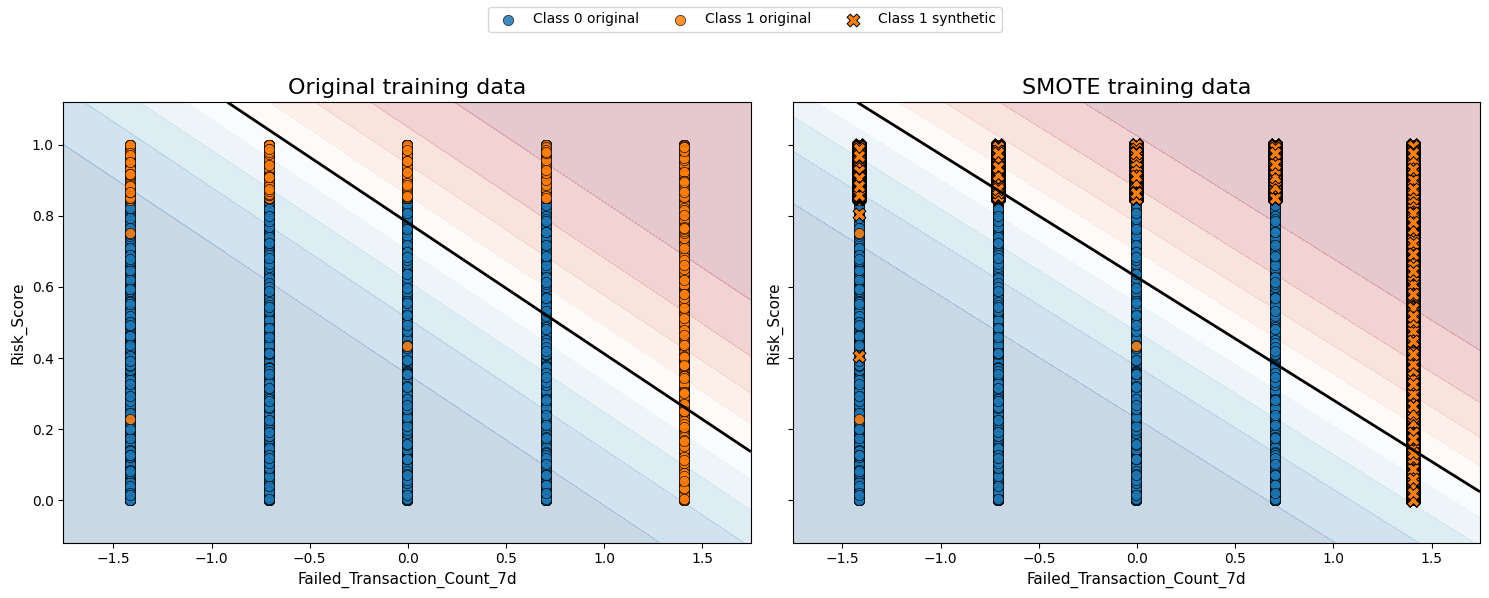

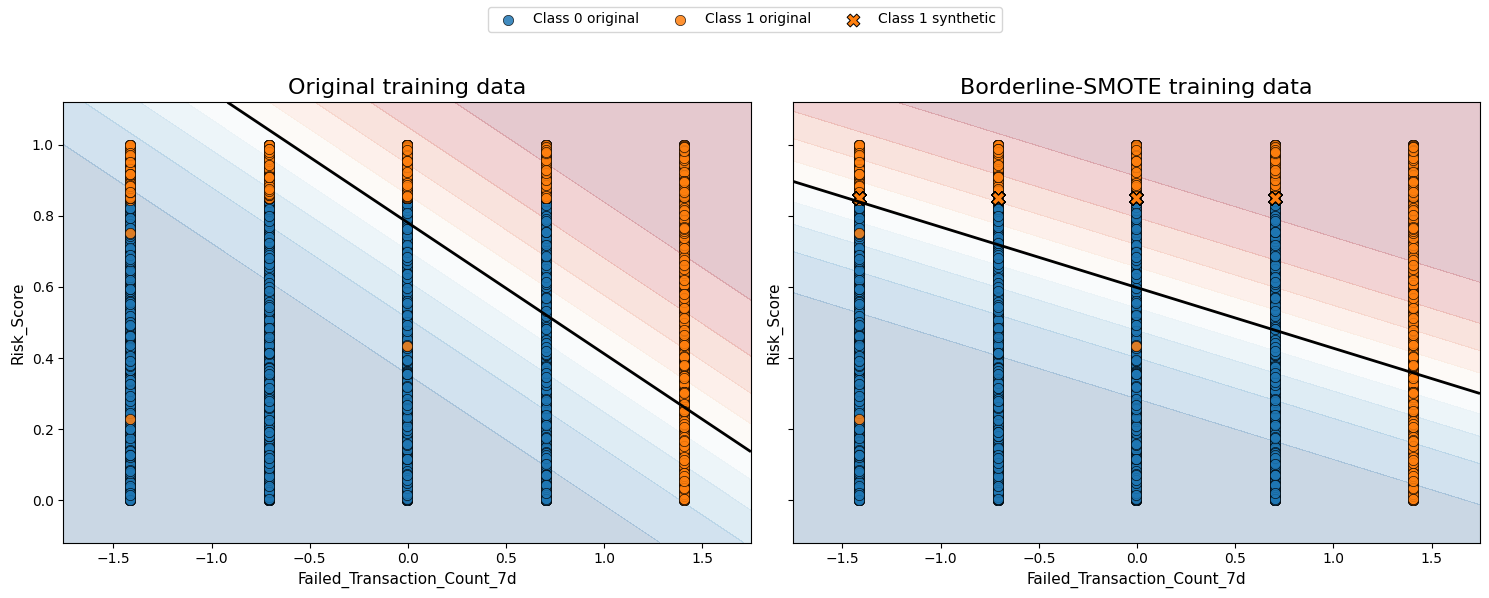

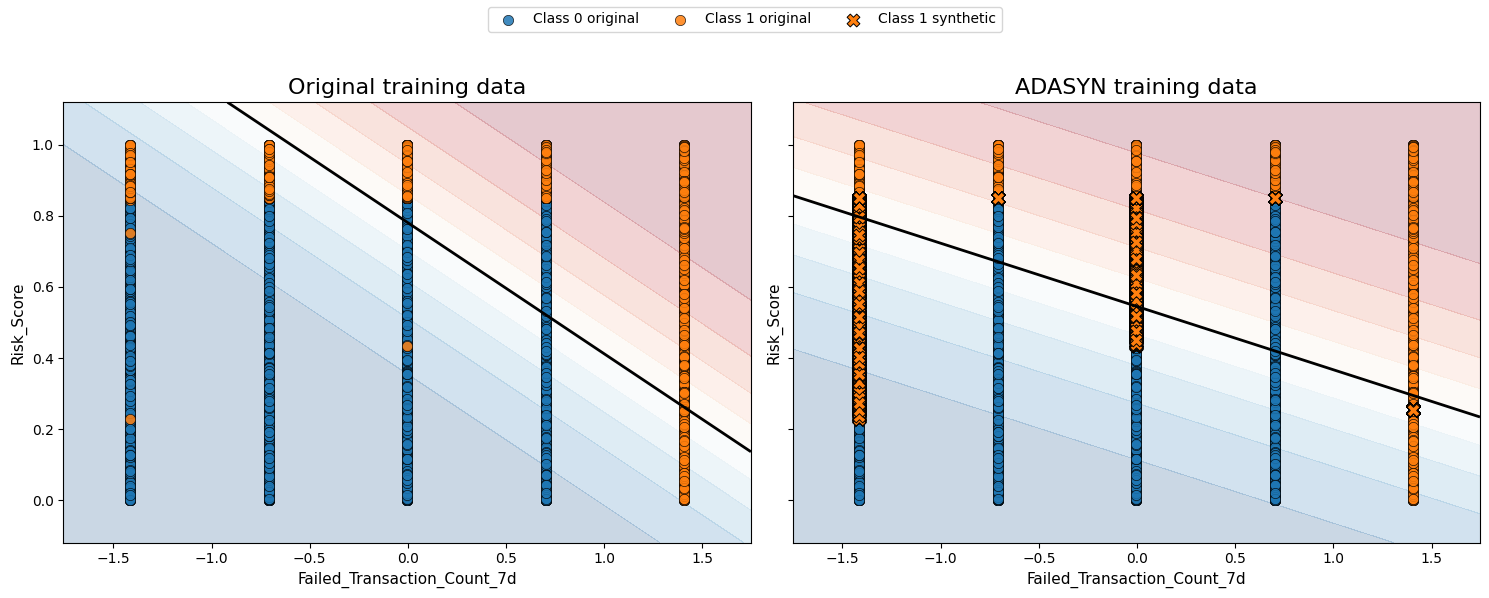

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



feature_x = 'Failed_Transaction_Count_7d'
feature_y = 'Risk_Score'


CLASS_COLORS = {
    0: 'tab:blue',
    1: 'tab:orange'
}

def get_plot_limits(*dfs, x_col, y_col, pad_ratio=0.12):
    all_df = pd.concat(dfs, axis=0)
    x_min, x_max = all_df[x_col].min(), all_df[x_col].max()
    y_min, y_max = all_df[y_col].min(), all_df[y_col].max()

    x_pad = (x_max - x_min) * pad_ratio if x_max > x_min else 1.0
    y_pad = (y_max - y_min) * pad_ratio if y_max > y_min else 1.0

    return (x_min - x_pad, x_max + x_pad, y_min - y_pad, y_max + y_pad)

def plot_decision_boundary(ax, model, xlim, ylim, alpha=0.22):
    xx, yy = np.meshgrid(
        np.linspace(xlim[0], xlim[1], 400),
        np.linspace(ylim[0], ylim[1], 400)
    )

    grid = pd.DataFrame({
        feature_x: xx.ravel(),
        feature_y: yy.ravel()
    })

    probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    # probability background
    ax.contourf(
        xx, yy, probs,
        levels=np.linspace(0, 1, 11),
        cmap='RdBu_r',
        alpha=alpha
    )

    # 0.5 decision boundary
    ax.contour(
        xx, yy, probs,
        levels=[0.5],
        colors='black',
        linewidths=2
    )

def plot_points(ax, X, y, title, synthetic_mask=None):
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)

    if synthetic_mask is None:
        synthetic_mask = np.zeros(len(X), dtype=bool)

    for cls in sorted(y.unique()):
        # original points
        mask_orig = (y == cls) & (~synthetic_mask)
        ax.scatter(
            X.loc[mask_orig, feature_x],
            X.loc[mask_orig, feature_y],
            c=CLASS_COLORS[cls],
            s=55,
            alpha=0.85,
            edgecolors='black',
            linewidths=0.5,
            label=f'Class {cls} original'
        )

        # synthetic points
        mask_syn = (y == cls) & (synthetic_mask)
        if mask_syn.sum() > 0:
            ax.scatter(
                X.loc[mask_syn, feature_x],
                X.loc[mask_syn, feature_y],
                c=CLASS_COLORS[cls],
                s=85,
                alpha=1.0,
                marker='X',
                edgecolors='black',
                linewidths=0.7,
                label=f'Class {cls} synthetic'
            )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(feature_x, fontsize=11)
    ax.set_ylabel(feature_y, fontsize=11)
    ax.grid(False)

# SYNTHETIC MASKS
# Original dataset has no synthetic points
orig_syn_mask = np.zeros(len(X_train_zz), dtype=bool)

# For SMOTE/ADASYN: first len(original) are original, rest are synthetic
smote_syn_mask = np.array([False] * len(X_train_zz) + [True] * (len(X_train_smote) - len(X_train_zz)))
bl_syn_mask = np.array([False] * len(X_train_zz) + [True] * (len(X_train_bl) - len(X_train_zz)))
adasyn_syn_mask = np.array([False] * len(X_train_zz) + [True] * (len(X_train_adasyn) - len(X_train_zz)))


x_min, x_max, y_min, y_max = get_plot_limits(
    X_train_zz, X_train_smote, X_train_adasyn,
    x_col=feature_x, y_col=feature_y
)


# ORIGINAL vs SMOTE
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

plot_decision_boundary(axes[0], clf_orig, (x_min, x_max), (y_min, y_max))
plot_points(axes[0], X_train_zz, y_train, "Original training data", synthetic_mask=orig_syn_mask)

plot_decision_boundary(axes[1], clf_smote, (x_min, x_max), (y_min, y_max))
plot_points(axes[1], X_train_smote, y_train_smote, "SMOTE training data", synthetic_mask=smote_syn_mask)

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

handles, labels = axes[1].get_legend_handles_labels()

seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
fig.legend(
    [h for h, _ in unique],
    [l for _, l in unique],
    loc='upper center',
    ncol=4,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


x_min, x_max, y_min, y_max = get_plot_limits(
    X_train_zz, X_train_smote, X_train_adasyn, X_train_bl,
    x_col=feature_x, y_col=feature_y
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

plot_decision_boundary(axes[0], clf_orig, (x_min, x_max), (y_min, y_max))
plot_points(axes[0], X_train_zz, y_train, "Original training data", synthetic_mask=orig_syn_mask)

plot_decision_boundary(axes[1], clf_bl, (x_min, x_max), (y_min, y_max))
plot_points(axes[1], X_train_bl, y_train_bl, "Borderline-SMOTE training data", synthetic_mask=bl_syn_mask)

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

handles, labels = axes[1].get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
fig.legend(
    [h for h, _ in unique],
    [l for _, l in unique],
    loc='upper center',
    ncol=4,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()





# ORIGINAL vs ADASYN

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

plot_decision_boundary(axes[0], clf_orig, (x_min, x_max), (y_min, y_max))
plot_points(axes[0], X_train_zz, y_train, "Original training data", synthetic_mask=orig_syn_mask)

plot_decision_boundary(axes[1], clf_adasyn, (x_min, x_max), (y_min, y_max))
plot_points(axes[1], X_train_adasyn, y_train_adasyn, "ADASYN training data", synthetic_mask=adasyn_syn_mask)

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

handles, labels = axes[1].get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
fig.legend(
    [h for h, _ in unique],
    [l for _, l in unique],
    loc='upper center',
    ncol=4,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# 3. UNDERSAMPLING

## 3.1 ENN (Edited Nearest Neighbours)

In [8]:
from imblearn.under_sampling import EditedNearestNeighbours, TomekLinks, ClusterCentroids
from collections import Counter

enn = EditedNearestNeighbours(
    n_neighbors=3,     # can try 5
    kind_sel='all'     # 'all' = stricter, 'mode' = softer
)

X_train_enn, y_train_enn = enn.fit_resample(X_train_zz, y_train)

X_train_enn = pd.DataFrame(X_train_enn, columns=X_train_zz.columns)
y_train_enn = pd.Series(y_train_enn, name='Fraud_Label')

print("After ENN:", Counter(y_train_enn))

After ENN: Counter({0: 20342, 1: 9641})


C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 3.2 Tomek Links (TL)

In [9]:
tl = TomekLinks()

X_train_tl, y_train_tl = tl.fit_resample(X_train_zz, y_train)

X_train_tl = pd.DataFrame(X_train_tl, columns=X_train_zz.columns)
y_train_tl = pd.Series(y_train_tl, name='Fraud_Label')

print("After TomekLinks:", Counter(y_train_tl))

After TomekLinks: Counter({0: 20356, 1: 9641})


C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 3.3 Cluster-Based Undersampling (CBU)

In [10]:
cc = ClusterCentroids(
    sampling_strategy='auto',
    random_state=42
)

X_train_cc, y_train_cc = cc.fit_resample(X_train_zz, y_train)

X_train_cc = pd.DataFrame(X_train_cc, columns=X_train_zz.columns)
y_train_cc = pd.Series(y_train_cc, name='Fraud_Label')

print("After ClusterCentroids:", Counter(y_train_cc))

C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


After ClusterCentroids: Counter({0: 9641, 1: 9641})


## 3.4. Usporedba modela

=== ENN model ===
[[6022  764]
 [1159 2055]]
              precision    recall  f1-score   support

           0     0.8386    0.8874    0.8623      6786
           1     0.7290    0.6394    0.6813      3214

    accuracy                         0.8077     10000
   macro avg     0.7838    0.7634    0.7718     10000
weighted avg     0.8034    0.8077    0.8041     10000

ROC-AUC: 0.8945602251129793
=== TOMEK LINKS model ===
[[6022  764]
 [1159 2055]]
              precision    recall  f1-score   support

           0     0.8386    0.8874    0.8623      6786
           1     0.7290    0.6394    0.6813      3214

    accuracy                         0.8077     10000
   macro avg     0.7838    0.7634    0.7718     10000
weighted avg     0.8034    0.8077    0.8041     10000

ROC-AUC: 0.8945564195548104
=== CLUSTER CENTROIDS model ===
[[5401 1385]
 [ 661 2553]]
              precision    recall  f1-score   support

           0     0.8910    0.7959    0.8408      6786
           1     0.6483 

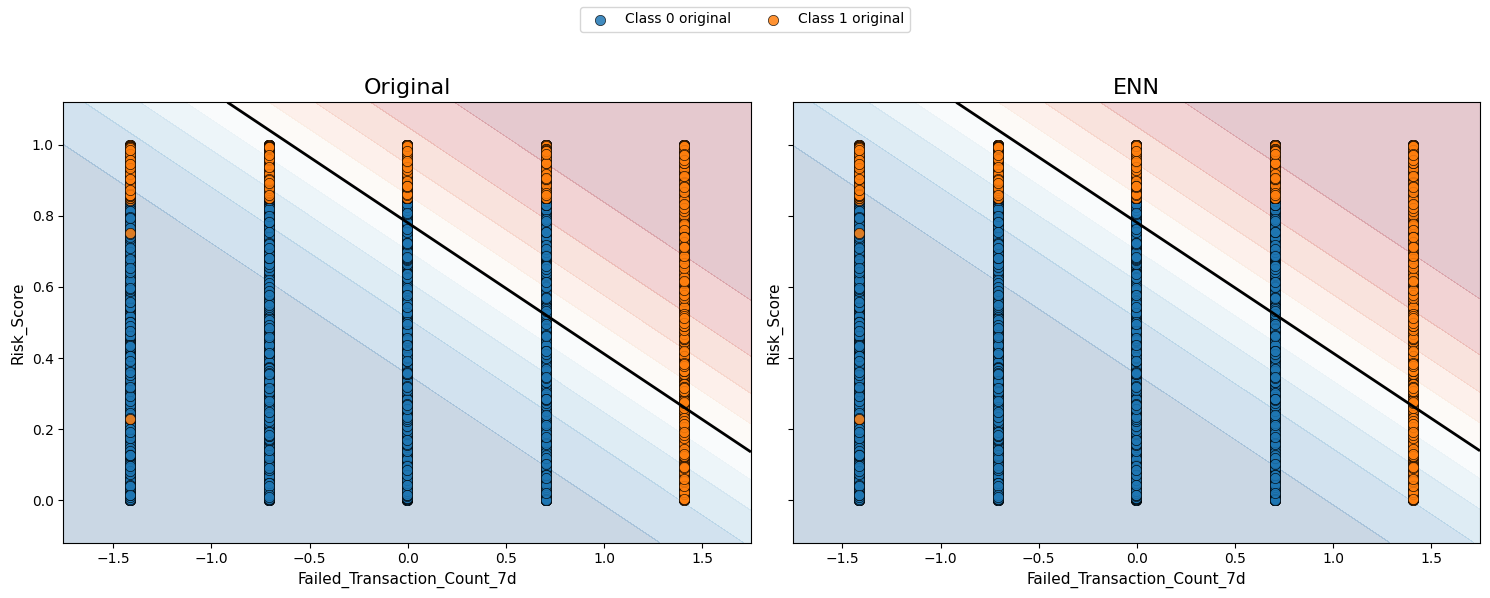

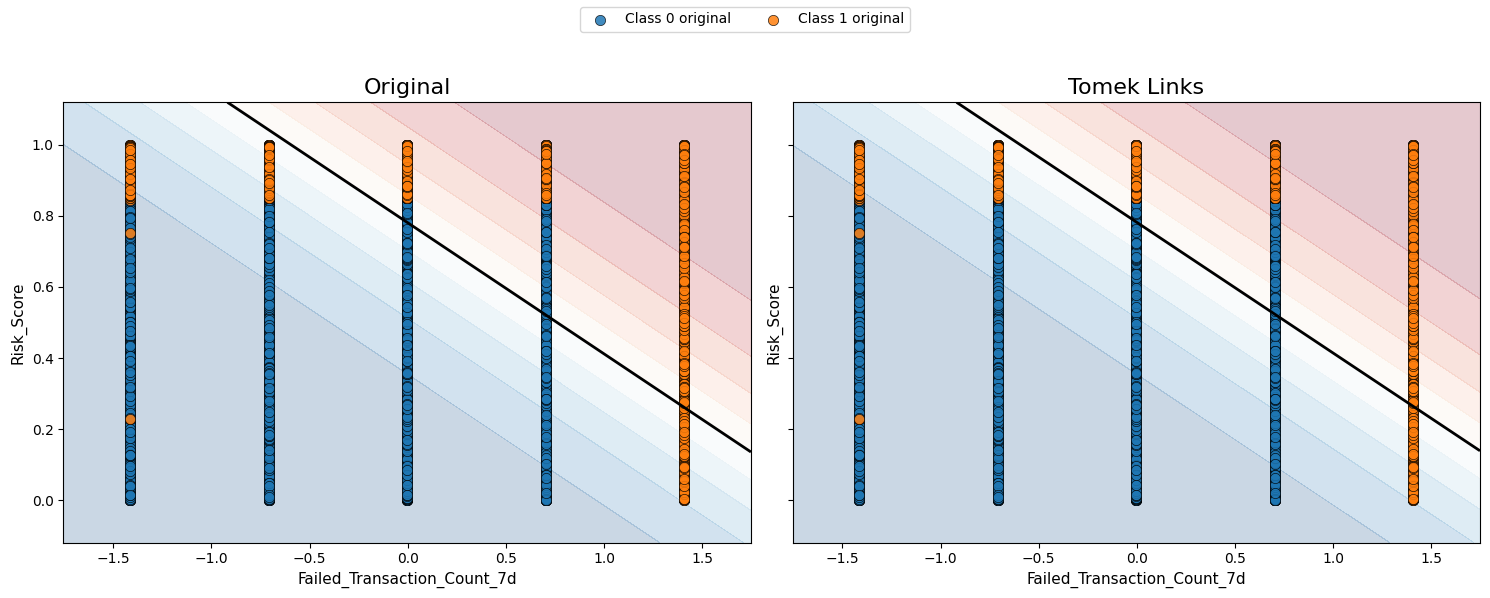

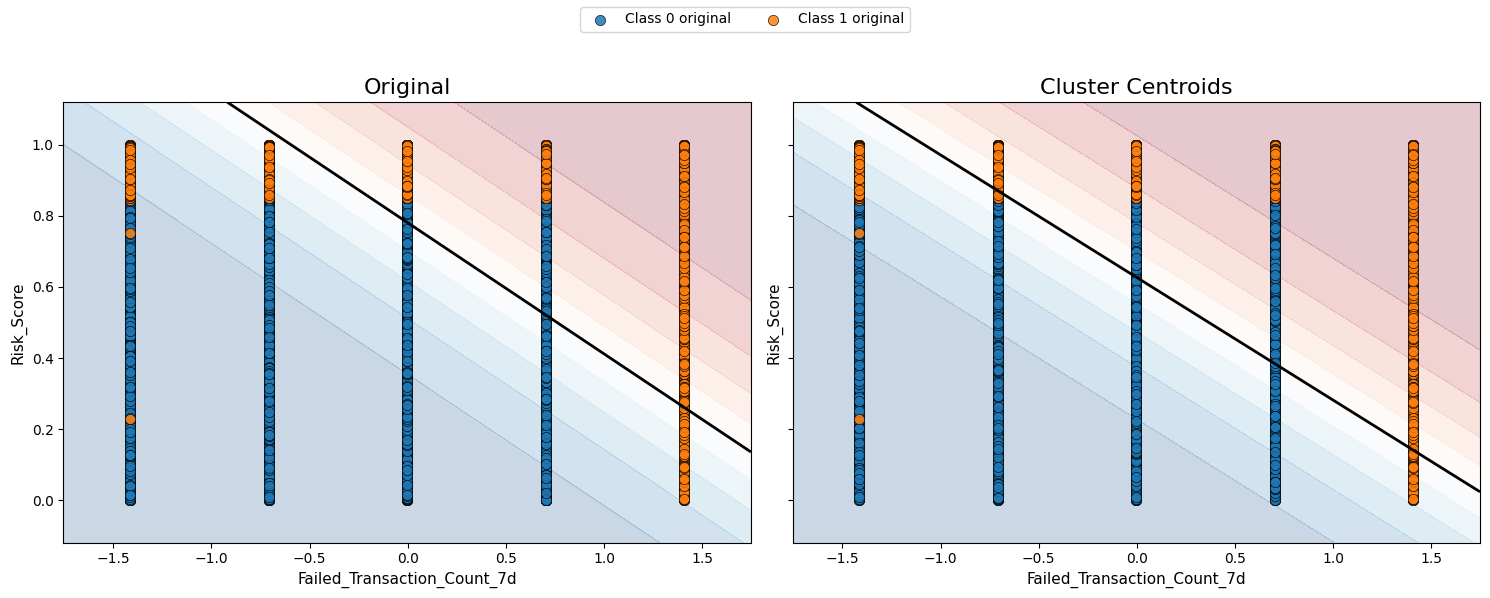

In [11]:
# ENN
clf_enn = LogisticRegression(max_iter=2000, random_state=42)
clf_enn.fit(X_train_enn, y_train_enn)

y_pred_enn = clf_enn.predict(X_test_zz)
y_prob_enn = clf_enn.predict_proba(X_test_zz)[:, 1]

print("=== ENN model ===")
print(confusion_matrix(y_test, y_pred_enn))
print(classification_report(y_test, y_pred_enn, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_enn))


# TL
clf_tl = LogisticRegression(max_iter=2000, random_state=42)
clf_tl.fit(X_train_tl, y_train_tl)

y_pred_tl = clf_tl.predict(X_test_zz)
y_prob_tl = clf_tl.predict_proba(X_test_zz)[:, 1]

print("=== TOMEK LINKS model ===")
print(confusion_matrix(y_test, y_pred_tl))
print(classification_report(y_test, y_pred_tl, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tl))


# CBU
clf_cc = LogisticRegression(max_iter=2000, random_state=42)
clf_cc.fit(X_train_cc, y_train_cc)

y_pred_cc = clf_cc.predict(X_test_zz)
y_prob_cc = clf_cc.predict_proba(X_test_zz)[:, 1]

print("=== CLUSTER CENTROIDS model ===")
print(confusion_matrix(y_test, y_pred_cc))
print(classification_report(y_test, y_pred_cc, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cc))



all_X = pd.concat(
    [X_train_zz, X_train_enn, X_train_tl, X_train_cc],
    axis=0
)

x_min, x_max = all_X[feature_x].min(), all_X[feature_x].max()
y_min, y_max = all_X[feature_y].min(), all_X[feature_y].max()

x_pad = 0.12 * (x_max - x_min) if x_max > x_min else 1.0
y_pad = 0.12 * (y_max - y_min) if y_max > y_min else 1.0

xlim = (x_min - x_pad, x_max + x_pad)
ylim = (y_min - y_pad, y_max + y_pad)

# No synthetic points in undersampling
orig_mask = np.zeros(len(X_train_zz), dtype=bool)
enn_mask = np.zeros(len(X_train_enn), dtype=bool)
tl_mask = np.zeros(len(X_train_tl), dtype=bool)
cc_mask = np.zeros(len(X_train_cc), dtype=bool)



# ORIG vs ENN
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

plot_decision_boundary(axes[0], clf_orig, xlim, ylim, alpha=0.22)
plot_points(axes[0], X_train_zz, y_train, "Original", synthetic_mask=orig_mask)

plot_decision_boundary(axes[1], clf_enn, xlim, ylim, alpha=0.22)
plot_points(axes[1], X_train_enn, y_train_enn, "ENN", synthetic_mask=enn_mask)

for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

handles, labels = axes[0].get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]

fig.legend(
    [h for h, _ in unique],
    [l for _, l in unique],
    loc='upper center',
    ncol=2,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()



# ORIG vs TL
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

plot_decision_boundary(axes[0], clf_orig, xlim, ylim, alpha=0.22)
plot_points(axes[0], X_train_zz, y_train, "Original", synthetic_mask=orig_mask)

plot_decision_boundary(axes[1], clf_tl, xlim, ylim, alpha=0.22)
plot_points(axes[1], X_train_tl, y_train_tl, "Tomek Links", synthetic_mask=tl_mask)

for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

handles, labels = axes[0].get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]

fig.legend(
    [h for h, _ in unique],
    [l for _, l in unique],
    loc='upper center',
    ncol=2,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


# ORIG vs CBU
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

plot_decision_boundary(axes[0], clf_orig, xlim, ylim, alpha=0.22)
plot_points(axes[0], X_train_zz, y_train, "Original", synthetic_mask=orig_mask)

plot_decision_boundary(axes[1], clf_cc, xlim, ylim, alpha=0.22)
plot_points(axes[1], X_train_cc, y_train_cc, "Cluster Centroids", synthetic_mask=cc_mask)

for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

handles, labels = axes[0].get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]

fig.legend(
    [h for h, _ in unique],
    [l for _, l in unique],
    loc='upper center',
    ncol=2,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# 4. Hibridne metode

- SMOTEEN, SMOTETomek



C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\Nikolina\source\DAP_demos

After SMOTEENN: Counter({1: 20347, 0: 20337})
After SMOTETomek: Counter({0: 20354, 1: 20354})

=== SMOTEENN model ===
[[5406 1380]
 [ 660 2554]]
              precision    recall  f1-score   support

           0     0.8912    0.7966    0.8413      6786
           1     0.6492    0.7946    0.7146      3214

    accuracy                         0.7960     10000
   macro avg     0.7702    0.7956    0.7779     10000
weighted avg     0.8134    0.7960    0.8006     10000

ROC-AUC: 0.894722809561983

=== SMOTETomek model ===
[[5406 1380]
 [ 661 2553]]
              precision    recall  f1-score   support

           0     0.8910    0.7966    0.8412      6786
           1     0.6491    0.7943    0.7144      3214

    accuracy                         0.7959     10000
   macro avg     0.7701    0.7955    0.7778     10000
weighted avg     0.8133    0.7959    0.8005     10000

ROC-AUC: 0.8947253313173961


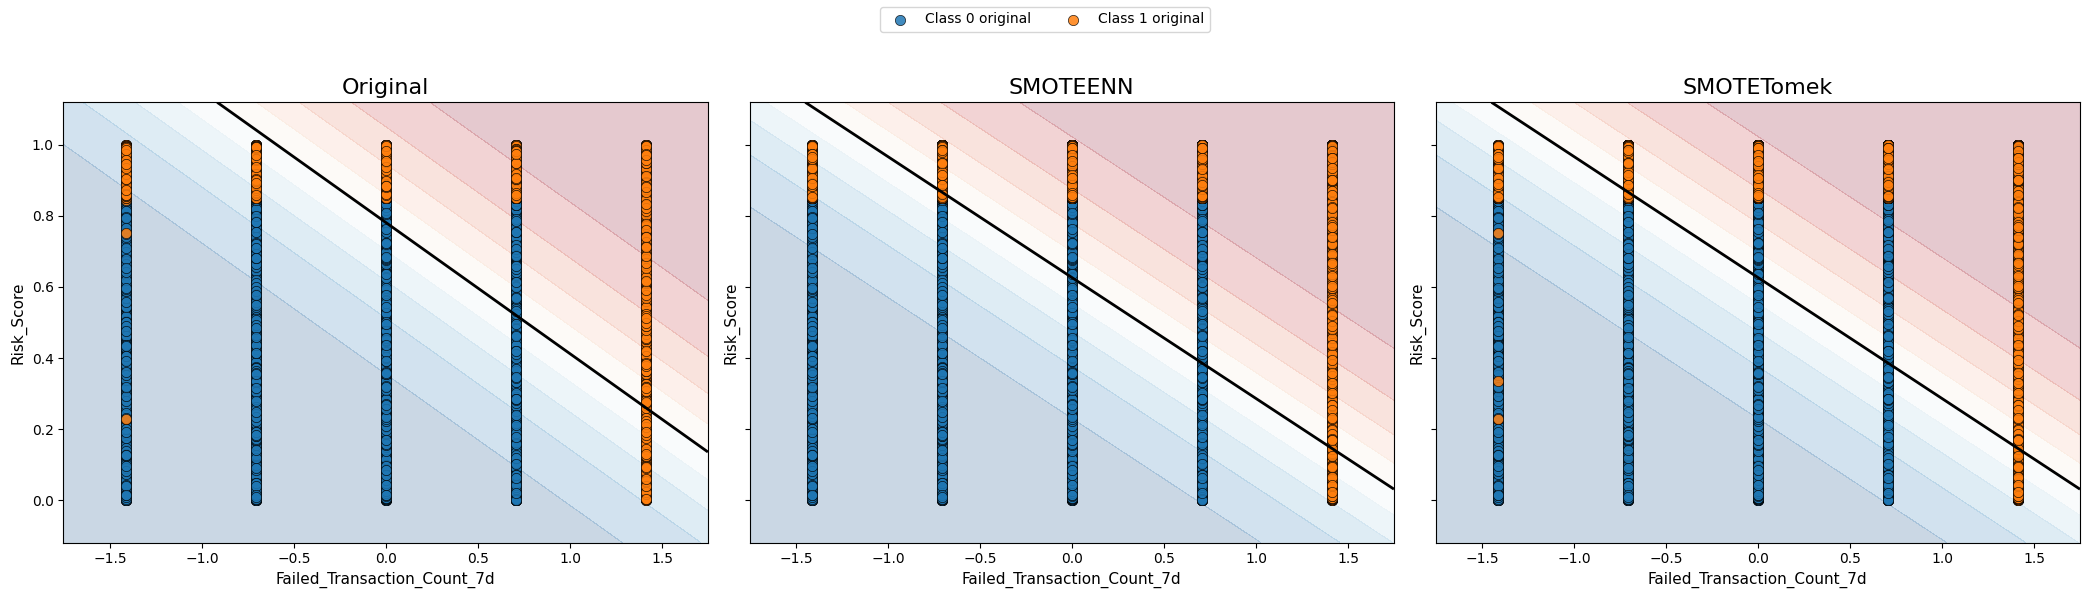

In [13]:
from imblearn.combine import SMOTEENN, SMOTETomek

# ------------------------------------------------------------
# SMOTE + ENN
# ------------------------------------------------------------
smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train_zz, y_train)

X_train_smoteenn = pd.DataFrame(X_train_smoteenn, columns=X_train_zz.columns)
y_train_smoteenn = pd.Series(y_train_smoteenn, name='Fraud_Label')

print("After SMOTEENN:", Counter(y_train_smoteenn))


# ------------------------------------------------------------
# SMOTE + TOMEK
# ------------------------------------------------------------
smotetomek = SMOTETomek(random_state=42)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(X_train_zz, y_train)

X_train_smotetomek = pd.DataFrame(X_train_smotetomek, columns=X_train_zz.columns)
y_train_smotetomek = pd.Series(y_train_smotetomek, name='Fraud_Label')

print("After SMOTETomek:", Counter(y_train_smotetomek))



#EVAL
clf_smoteenn = LogisticRegression(max_iter=2000, random_state=42)
clf_smoteenn.fit(X_train_smoteenn, y_train_smoteenn)

clf_smotetomek = LogisticRegression(max_iter=2000, random_state=42)
clf_smotetomek.fit(X_train_smotetomek, y_train_smotetomek)

for name, clf in [
    ("SMOTEENN", clf_smoteenn),
    ("SMOTETomek", clf_smotetomek),
]:
    y_pred = clf.predict(X_test_zz)
    y_prob = clf.predict_proba(X_test_zz)[:, 1]

    print(f"\n=== {name} model ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


all_X = pd.concat(
    [X_train_zz, X_train_smoteenn, X_train_smotetomek],
    axis=0
)

x_min, x_max = all_X[feature_x].min(), all_X[feature_x].max()
y_min, y_max = all_X[feature_y].min(), all_X[feature_y].max()

x_pad = 0.12 * (x_max - x_min) if x_max > x_min else 1.0
y_pad = 0.12 * (y_max - y_min) if y_max > y_min else 1.0

xlim = (x_min - x_pad, x_max + x_pad)
ylim = (y_min - y_pad, y_max + y_pad)

orig_mask = np.zeros(len(X_train_zz), dtype=bool)
smoteenn_mask = np.zeros(len(X_train_smoteenn), dtype=bool)
smotetomek_mask = np.zeros(len(X_train_smotetomek), dtype=bool)


fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)

plot_decision_boundary(axes[0], clf_orig, xlim, ylim, alpha=0.22)
plot_points(axes[0], X_train_zz, y_train, "Original", synthetic_mask=orig_mask)

plot_decision_boundary(axes[1], clf_smoteenn, xlim, ylim, alpha=0.22)
plot_points(axes[1], X_train_smoteenn, y_train_smoteenn, "SMOTEENN", synthetic_mask=smoteenn_mask)

plot_decision_boundary(axes[2], clf_smotetomek, xlim, ylim, alpha=0.22)
plot_points(axes[2], X_train_smotetomek, y_train_smotetomek, "SMOTETomek", synthetic_mask=smotetomek_mask)

for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

handles, labels = axes[0].get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]

fig.legend(
    [h for h, _ in unique],
    [l for _, l in unique],
    loc='upper center',
    ncol=2,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()